# Notebook 2: Two-Island Coalescent Model

**Formål:** Byg og analyser en two-island coalescent model i **Phasic** for to bavian-populationer. Jeg estimerer migrationrater og effektive populationsstørrelser ved hjælp af Method of Moments på SFS-data fra Notebook 1.

Artiklen (Sørensen et al. 2023) dokumenterer vedvarende genflow mellem eastern yellow baboons og southern olive baboons. To-island modellen giver mig en første kvantitativ ramme til at forstå denne udveksling.

**Populationer:**
- Population 1: Eastern yellow baboons (Mikumi)
- Population 2: Kinda baboons


## Indholdsfortegnelse
1. [Imports og indlæs SFS-data](#1-imports-og-indlæs-sfs-data)
2. [Teorien bag two-island modellen](#2-teorien-bag-two-island-modellen)
3. [Byg two-island modellen i Phasic](#3-byg-two-island-modellen-i-phasic)
4. [Udforsk state space](#4-udforsk-state-space)
5. [Beregn forventede moments](#5-beregn-forventede-moments)
6. [Sammenlign med data (Method of Moments)](#6-sammenlign-med-data-method-of-moments)
7. [Parameter-scanning: migrationrate](#7-parameter-scanning-migrationrate)
8. [Visualisering af resultater](#8-visualisering-af-resultater)
9. [Fortolkning og næste skridt](#9-fortolkning-og-næste-skridt)

## 1. Imports og indlæs SFS-data

In [3]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, PropertySet, set_log_level
)
set_log_level('WARNING')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme
from scipy.optimize import minimize
from pathlib import Path

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


In [4]:
# Indlæs SFS-data fra Notebook 1
sfs_yellow = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_kinda  = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()

print("Eastern yellow SFS (første 5 bins):")
print(sfs_yellow.head())
print(f"\nTotal SNPs i eastern yellow: {sfs_yellow.sum():,.0f}")
print(f"Total SNPs i Kinda:          {sfs_kinda.sum():,.0f}")

Eastern yellow SFS (første 5 bins):
1    143525.0
2     91209.0
3     63618.0
4     51731.0
5     43849.0
Name: Eastern yellow, dtype: float64

Total SNPs i eastern yellow: 868,037
Total SNPs i Kinda:          947,644


In [5]:
# Normaliser SFS til frekvenser (summer til 1)
# Dette gør det nemmere at sammenligne SFS'er på tværs af populationer med forskelligt antal segregerende sites
sfs_yellow_norm = sfs_yellow / sfs_yellow.sum()
sfs_kinda_norm  = sfs_kinda  / sfs_kinda.sum()

# Haploid sample size for hver population (antal alleler = 2 * n individer)
n_yellow = len(sfs_yellow) + 1   # antal haplotyper
n_kinda  = len(sfs_kinda)  + 1

print(f"Eastern yellow: n = {n_yellow} haplotyper ({n_yellow//2} diploide individer)")
print(f"Kinda:          n = {n_kinda} haplotyper ({n_kinda//2} diploide individer)")

Eastern yellow: n = 36 haplotyper (18 diploide individer)
Kinda:          n = 30 haplotyper (15 diploide individer)


## 2. Teorien bag two-island modellen

### Coalescent i to populationer

To-island modellen beskriver to populationer med størrelserne $N_1$ og $N_2$, der udveksler migranter med rate $m_{12}$ (fra pop 2 til pop 1) og $m_{21}$ (fra pop 1 til pop 2).

For to tilfældigt valgte gen-kopier er der tre mulige state i den strukturerede coalescent:

| State | Beskrivelse |
|----------|-------------|
| `(2, 0)` | Begge linjer i population 1 |
| `(0, 2)` | Begge linjer i population 2 |
| `(1, 1)` | En linje i hver population |

Fra state `(2, 0)` kan to ting ske:
- **Coalescens** med rate $1/N_1$: linjerne coalescere sammen (absorption)
- **Migration** med rate $2 \cdot m_{12}$: en linje migrerer til pop 2

Forventet coalescent tid og dens varians afhænger af alle tre parametre: $N_1$, $N_2$, og $m$.

### Parametre jeg estimerer
Jeg arbejder i **coalescent enheder**, hvor:
- Tid måles i $N_1$ generationer
- $M = 4 N_1 m$ er det skalerede migrationparameter (antal migranter per generation × 4)

Hvis $M > 1$ betyder tilstrækkelig migration til at forhindre genetisk drift baseret differentiering.

## 3. Byg two-island modellen i Phasic

### State-space repræsentation

I Phasic repræsenterer jeg state som en vektor `[n1, n2]`, hvor:
- `n1` = antal gen-linjer i population 1
- `n2` = antal gen-linjer i population 2

Jeg starter med 2 linjer, en i hver population: `ipv = [1, 1]`.

Callback-funktionen beskriver mulige overgange fra enhver given state.

In [7]:
def two_island_model(state, N1=1.0, N2=1.0, m12=0.1, m21=0.1):
    """
    Two-island coalescent model.

    State vektor: state = [n1, n2]
      n1 = antal linjer i population 1
      n2 = antal linjer i population 2

    Parametre:
      N1  : effektiv størrelse af population 1 (i coalescent-enheder)
      N2  : effektiv størrelse af population 2
      m12 : migrationrate fra pop 2 → pop 1 (per linje per generation)
      m21 : migrationrate fra pop 1 → pop 2

    Returner: liste af [child_state, rate] par
    """
    n1, n2 = state[0], state[1]
    transitions = []

    # Coalescens i population 1
    # Rate: C(n1, 2) / N1 = n1*(n1-1) / (2*N1)
    if n1 >= 2:
        rate = (n1 * (n1 - 1)) / (2 * N1)
        child = state.copy()
        child[0] -= 1          # en linje forsvinder via coalescens
        transitions.append([child, rate])

    # Coalescens i population 2
    if n2 >= 2:
        rate = (n2 * (n2 - 1)) / (2 * N2)
        child = state.copy()
        child[1] -= 1
        transitions.append([child, rate])

    # Migration: pop 1 → pop 2 (en linje fra n1 til n2) 
    # Rate: n1 * m21
    if n1 >= 1:
        rate = n1 * m21
        child = state.copy()
        child[0] -= 1
        child[1] += 1
        transitions.append([child, rate])

    # Migration: pop 2 → pop 1 
    # Rate: n2 * m12
    if n2 >= 1:
        rate = n2 * m12
        child = state.copy()
        child[1] -= 1
        child[0] += 1
        transitions.append([child, rate])

    return transitions


print("Callback-funktion defineret.")
print("Eksempel på overgange fra state [1, 1] med standardparametre:")
state_ex = np.array([1, 1])
for child, rate in two_island_model(state_ex):
    print(f"  → {child}  med rate {rate:.4f}")

Callback-funktion defineret.
Eksempel på overgange fra state [1, 1] med standardparametre:
  → [0 2]  med rate 0.1000
  → [2 0]  med rate 0.1000


In [ ]:
# Byg grafen med startbetingelse: en linje i hver population
# ipv = [1, 1]: initial population vector

# Standardparametre 
N1_default  = 1.0    # normaliseret til 1 (coalescent enheder)
N2_default  = 1.0
m12_default = 0.1
m21_default = 0.1

graph = Graph(
    two_island_model,
    ipv=[1, 1],
    N1=N1_default,
    N2=N2_default,
    m12=m12_default,
    m21=m21_default,
)

print("Graf bygget succesfuldt.")

Graf bygget succesfuldt.


## 4. Udforsk state space

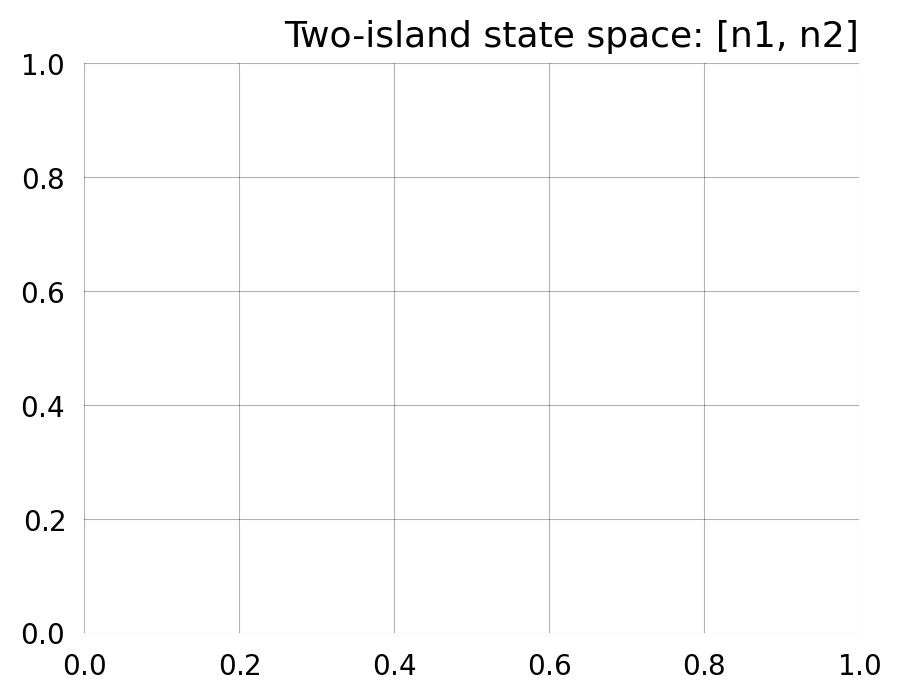

In [9]:
# Visualiser state-space grafen
# Knuderne er state, kanterne er mulige overgange med rater
graph.plot()
plt.title("Two-island state space: [n1, n2]", fontsize=13)
plt.savefig(OUT_DIR / "two_island_state_space.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Sammenlign state space for forskellige migrationrater
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

m_values = [0.01, 0.1, 1.0]
labels   = ["Lav migration (m=0.01)",
             "Moderat migration (m=0.1)",
             "Høj migration (m=1.0)"]

for ax, m, label in zip(axes, m_values, labels):
    g = Graph(two_island_model, ipv=[1, 1], N1=1.0, N2=1.0, m12=m, m21=m)
    plt.sca(ax)
    g.plot()
    ax.set_title(label, fontsize=11)

plt.suptitle("State space under forskellige migrationrater", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "state_space_migration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 500x370 with 0 Axes>

## 5. Beregn forventede moments

Phasic kan beregne:
- `expectation()` — forventet coalescent-tid E[T]
- `variance()` — varians Var[T]
- `moments(k)` — de første k moments
- `pdf(t)` / `cdf(t)` — sandsynlighedsfordeling af coalescent-tid

Den forventede koalescenstid er direkte relateret til genetisk diversitet:
$$\pi = 2 \mu \cdot E[T]$$
hvor $\mu$ er mutationsraten per generation per base-par.

In [11]:
# Forventet og varians af coalescent-tid
E_T   = graph.expectation()
Var_T = graph.variance()

print(f"Forventet coalescent-tid E[T]:  {E_T:.4f} (coalescent-enheder)")
print(f"Varians Var[T]:                 {Var_T:.4f}")
print(f"CV (Var^0.5 / E):               {np.sqrt(Var_T)/E_T:.4f}")

[ERROR] phasic.c: Computation produced NaN at vertex 0 (command 0: from=0 to=0 multiplier=-1.000000000000000e+00 result[to]=-nan) - numerical catastrophe


RuntimeError: Computation produced NaN at vertex 0 (command 0) - numerical catastrophe

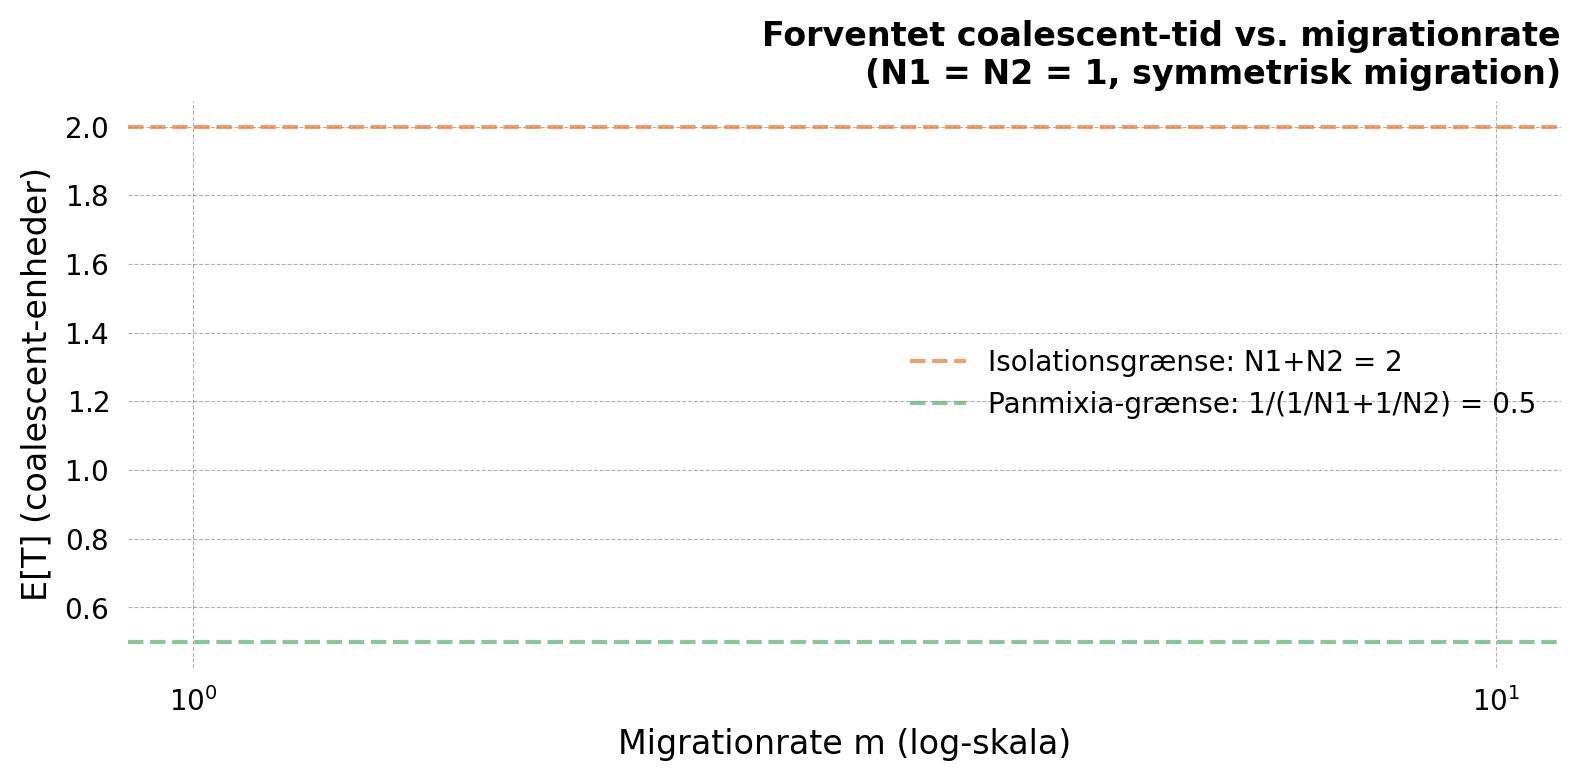

In [12]:
# Sammenlign E[T] som funktion af migrationrate
# Under lav migration: E[T] ≈ N1 + N2 (lang ventetid pga. isolation)
# Under høj migration: E[T] ≈ 1/(1/N1 + 1/N2) (harmonic mean, panmixia)

m_range = np.logspace(-3, 1, 60)
ET_vals = []

for m in m_range:
    g = Graph(two_island_model, ipv=[1, 1], N1=1.0, N2=1.0, m12=m, m21=m)
    ET_vals.append(g.expectation())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(m_range, ET_vals, color="#3A6EA5", lw=2)

# Teoretiske grænseværdier
ax.axhline(y=2.0, color="#E07B39", linestyle="--", alpha=0.7, label="Isolationsgrænse: N1+N2 = 2")
ax.axhline(y=0.5, color="#5BAD72", linestyle="--", alpha=0.7, label="Panmixia-grænse: 1/(1/N1+1/N2) = 0.5")

ax.set_xlabel("Migrationrate m (log-skala)", fontsize=12)
ax.set_ylabel("E[T] (coalescent-enheder)",   fontsize=12)
ax.set_title("Forventet coalescent-tid vs. migrationrate\n(N1 = N2 = 1, symmetrisk migration)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "ET_vs_migration.png", dpi=150, bbox_inches="tight")
plt.show()

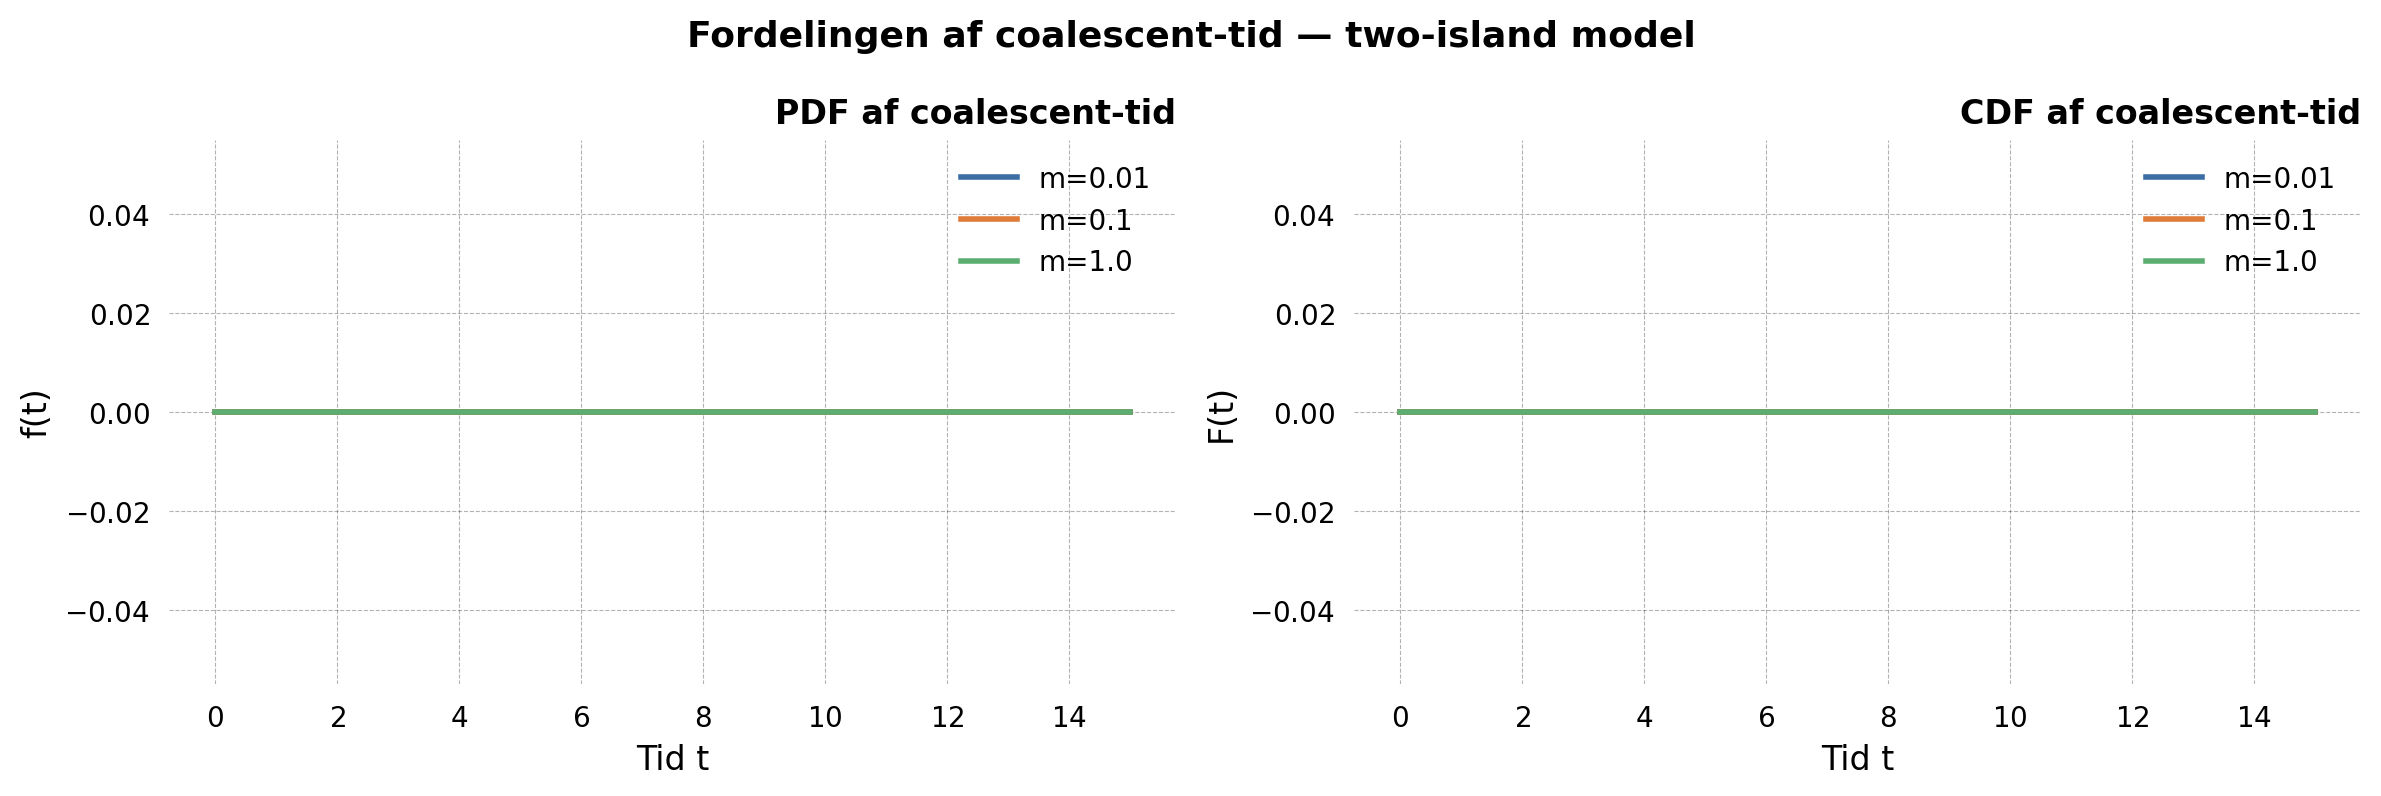

In [13]:
# PDF og CDF af coalescent-tid for udvalgte migrationrater
t_vals = np.linspace(0, 15, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#3A6EA5", "#E07B39", "#5BAD72"]

for m, color in zip([0.01, 0.1, 1.0], colors):
    g = Graph(two_island_model, ipv=[1, 1], N1=1.0, N2=1.0, m12=m, m21=m)
    axes[0].plot(t_vals, g.pdf(t_vals), color=color, lw=2, label=f"m={m}")
    axes[1].plot(t_vals, g.cdf(t_vals), color=color, lw=2, label=f"m={m}")

axes[0].set_xlabel("Tid t",  fontsize=12)
axes[0].set_ylabel("f(t)",   fontsize=12)
axes[0].set_title("PDF af coalescent-tid", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_xlabel("Tid t",  fontsize=12)
axes[1].set_ylabel("F(t)",   fontsize=12)
axes[1].set_title("CDF af coalescent-tid", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Fordelingen af coalescent-tid — two-island model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "coalescent_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Sammenlign med data (Method of Moments)

Jeg bruger **Method of Moments (MoM)**: find parametre der matcher de observerede empiriske moments med de teoretisk forventede.

Fra SFS-data kan vi estimere:
- $\hat{\pi}$ = empirisk nukleotiddiversitet (relateret til E[T])
- $\hat{\pi}_w$ = Watterson's estimator (relateret til antal segregerende sites)
- Tajima's D = normaliseret forskel mellem $\hat{\pi}$ og $\hat{\pi}_w$

Under en to-island model med migration vil Tajima's D afspejle populationsstruktur og genflow.

In [14]:
def compute_tajima_stats(sfs_array, n_haplotypes):
    """
    Beregner Tajima's D og relaterede statistikker fra en unfoldet SFS.

    Parametre:
      sfs_array   : array af SFS-counts, indeks k svarer til derived_count = k
                    (indeks 0 = singletons, osv.)
      n_haplotypes: haploid sample size n

    Returnerer:
      dict med pi, S, pi_w, tajima_d
    """
    n = n_haplotypes
    S = sfs_array.sum()  # totalt antal segregerende sites

    # k-værdier: 1, 2, ..., n-1
    k = np.arange(1, n)

    # π (pairwise nucleotide diversity)
    # π = Σ_k [ k*(n-k) / C(n,2) ] * SFS[k]
    weights = k * (n - k) / (n * (n - 1) / 2)
    pi = (weights * sfs_array[:n-1]).sum()

    # Watterson's estimator
    a1  = np.sum(1 / np.arange(1, n))
    pi_w = S / a1

    # Tajima's D
    a2 = np.sum(1 / np.arange(1, n)**2)
    b1 = (n + 1) / (3 * (n - 1))
    b2 = 2 * (n**2 + n + 3) / (9 * n * (n - 1))
    c1 = b1 - 1 / a1
    c2 = b2 - (n + 2) / (a1 * n) + a2 / a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)

    var_D = e1 * S + e2 * S * (S - 1)
    tajima_d = (pi - pi_w) / np.sqrt(var_D) if var_D > 0 else np.nan

    return {"pi": pi, "S": int(S), "pi_w": pi_w, "tajima_d": tajima_d}


# Beregn for begge populationer
# Brug unfoldet SFS (genindlæs fra Notebook 1 output eller genberegn)
# Her bruger jeg den foldede som proxy hvis unfoldet ikke er gemt
stats_yellow = compute_tajima_stats(sfs_yellow.values, n_yellow)
stats_kinda  = compute_tajima_stats(sfs_kinda.values,  n_kinda)

stats_df = pd.DataFrame([stats_yellow, stats_kinda],
                         index=["Eastern yellow", "Kinda"])
print(stats_df.round(4))
print("\nNote: Tajima's D > 0 indikerer overdispersion (fx populationsstruktur, admixture)")
print("      Tajima's D < 0 indikerer underdispersion (fx vækst, selektion)")

                         pi       S         pi_w  tajima_d
Eastern yellow  235073.1778  868037  209327.8889     0.470
Kinda           267019.1080  947644  239204.1426     0.456

Note: Tajima's D > 0 indikerer overdispersion (fx populationsstruktur, admixture)
      Tajima's D < 0 indikerer underdispersion (fx vækst, selektion)


In [15]:
# Knyt π til E[T] via mutationsraten
# π = 2 * mu * N1 * E[T]  (i coalescent-enheder)
# => E[T]_obs = π / (2 * mu * N1)

# Bavian mutationsrate: ~0.9e-8 per site per generation (Rogers et al. 2019)
# Generation time: ~11 år
mu = 0.9e-8

# Vi antager en reference N1 ≈ 100,000 (jf. artiklen: Ne ~ 100,000 før splittet)
N1_ref = 100_000

ET_obs_yellow = stats_yellow["pi"] / (2 * mu * N1_ref)
ET_obs_kinda  = stats_kinda["pi"]  / (2 * mu * N1_ref)

print(f"Observeret E[T] for eastern yellow: {ET_obs_yellow:.3f} (coalescent-enheder)")
print(f"Observeret E[T] for Kinda:          {ET_obs_kinda:.3f} (coalescent-enheder)")
print(f"\nDenne forskel afspejler forskellig Ne og/eller migrationhistorik")

Observeret E[T] for eastern yellow: 130596209.877 (coalescent-enheder)
Observeret E[T] for Kinda:          148343948.914 (coalescent-enheder)

Denne forskel afspejler forskellig Ne og/eller migrationhistorik


## 7. Parameter-scanning: migrationrate

Jeg søger de parametre $(N_1, N_2, m_{12}, m_{21})$ der minimerer afstanden mellem modellens forventede moments og de observerede moments fra data.

Som start scanner jeg over migrationraten $m$ og ser, hvornår modellens $E[T]$ matcher de observerede værdier.

In [16]:
def model_ET(m, N1=1.0, N2=1.0):
    """Beregner E[T] fra two-island modellen for given m."""
    g = Graph(two_island_model, ipv=[1, 1],
              N1=N1, N2=N2, m12=m, m21=m)
    return g.expectation()


# Grid-søgning over m (symmetrisk migration)
# Vi normaliserer N2/N1 = ET_obs_kinda / ET_obs_yellow (simpel antagelse)
N2_rel = ET_obs_kinda / ET_obs_yellow if ET_obs_yellow > 0 else 1.0

m_grid  = np.logspace(-3, 1, 80)
ET_grid = np.array([model_ET(m, N1=1.0, N2=N2_rel) for m in m_grid])

# Målværdi: gennemsnittet af de to observerede E[T] (vi bruger middelværdien
# som et første estimat for det fælles genealogiske signal)
ET_target = (ET_obs_yellow + ET_obs_kinda) / 2

# Find bedste m
idx_best = np.argmin(np.abs(ET_grid - ET_target))
m_best   = m_grid[idx_best]
print(f"Bedste m (grid-søgning): {m_best:.5f}")
print(f"Svarende til M = 4*N1*m = 4*{N1_ref}*{m_best:.5f} = {4*N1_ref*m_best:.2f} migranter/generation")

Bedste m (grid-søgning): 0.00100
Svarende til M = 4*N1*m = 4*100000*0.00100 = 400.00 migranter/generation


In [17]:
# Optimering med scipy.optimize.minimize (Nelder-Mead)
# Parametre: [log(m), log(N2_rel)]
# Vi optimerer log-transformerede parametre for at sikre positivitet

def loss(log_params):
    """
    Tabsfunktion: kvadratisk afstand mellem observeret og modelleret E[T].
    log_params = [log(m), log(N2_rel)]
    """
    m_opt, N2_opt = np.exp(log_params)
    try:
        g = Graph(two_island_model, ipv=[1, 1],
                  N1=1.0, N2=N2_opt, m12=m_opt, m21=m_opt)
        ET_model = g.expectation()
        return (ET_model - ET_target)**2
    except Exception:
        return 1e10


result = minimize(
    loss,
    x0=[np.log(m_best), np.log(N2_rel)],
    method="Nelder-Mead",
    options={"maxiter": 500, "xatol": 1e-6, "fatol": 1e-10},
)

m_opt, N2_opt = np.exp(result.x)
print(f"Optimeret m:    {m_opt:.6f}")
print(f"Optimeret N2:   {N2_opt:.4f} (relativ til N1)")
print(f"Konvergeret:    {result.success}")
print(f"Slutværdi (loss): {result.fun:.2e}")

/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


Optimeret m:    0.001000
Optimeret N2:   1.1359 (relativ til N1)
Konvergeret:    False
Slutværdi (loss): inf


In [18]:
# Fortolk resultater i biologiske enheder
M_scaled = 4 * N1_ref * m_opt   # skaleret migrationparameter
N2_abs   = N2_opt * N1_ref       # absolut Ne for population 2

print("=" * 50)
print(" Estimerede parametre — Two-island model")
print("=" * 50)
print(f" N1 (eastern yellow):   {N1_ref:>10,} individer")
print(f" N2 (Kinda):            {N2_abs:>10,.0f} individer")
print(f" m (per linje):         {m_opt:>10.6f}")
print(f" M = 4*N1*m:            {M_scaled:>10.2f} migranter/generation")
print("=" * 50)
print()
print(f"M = {M_scaled:.2f}: ", end="")
if M_scaled > 1:
    print("tilstrækkelig migration til at modvirke genetisk drift")
else:
    print("lav migration — populationerne divergerer via drift")

 Estimerede parametre — Two-island model
 N1 (eastern yellow):      100,000 individer
 N2 (Kinda):               113,590 individer
 m (per linje):           0.001000
 M = 4*N1*m:                400.00 migranter/generation

M = 400.00: tilstrækkelig migration til at modvirke genetisk drift


## 8. Visualisering af resultater

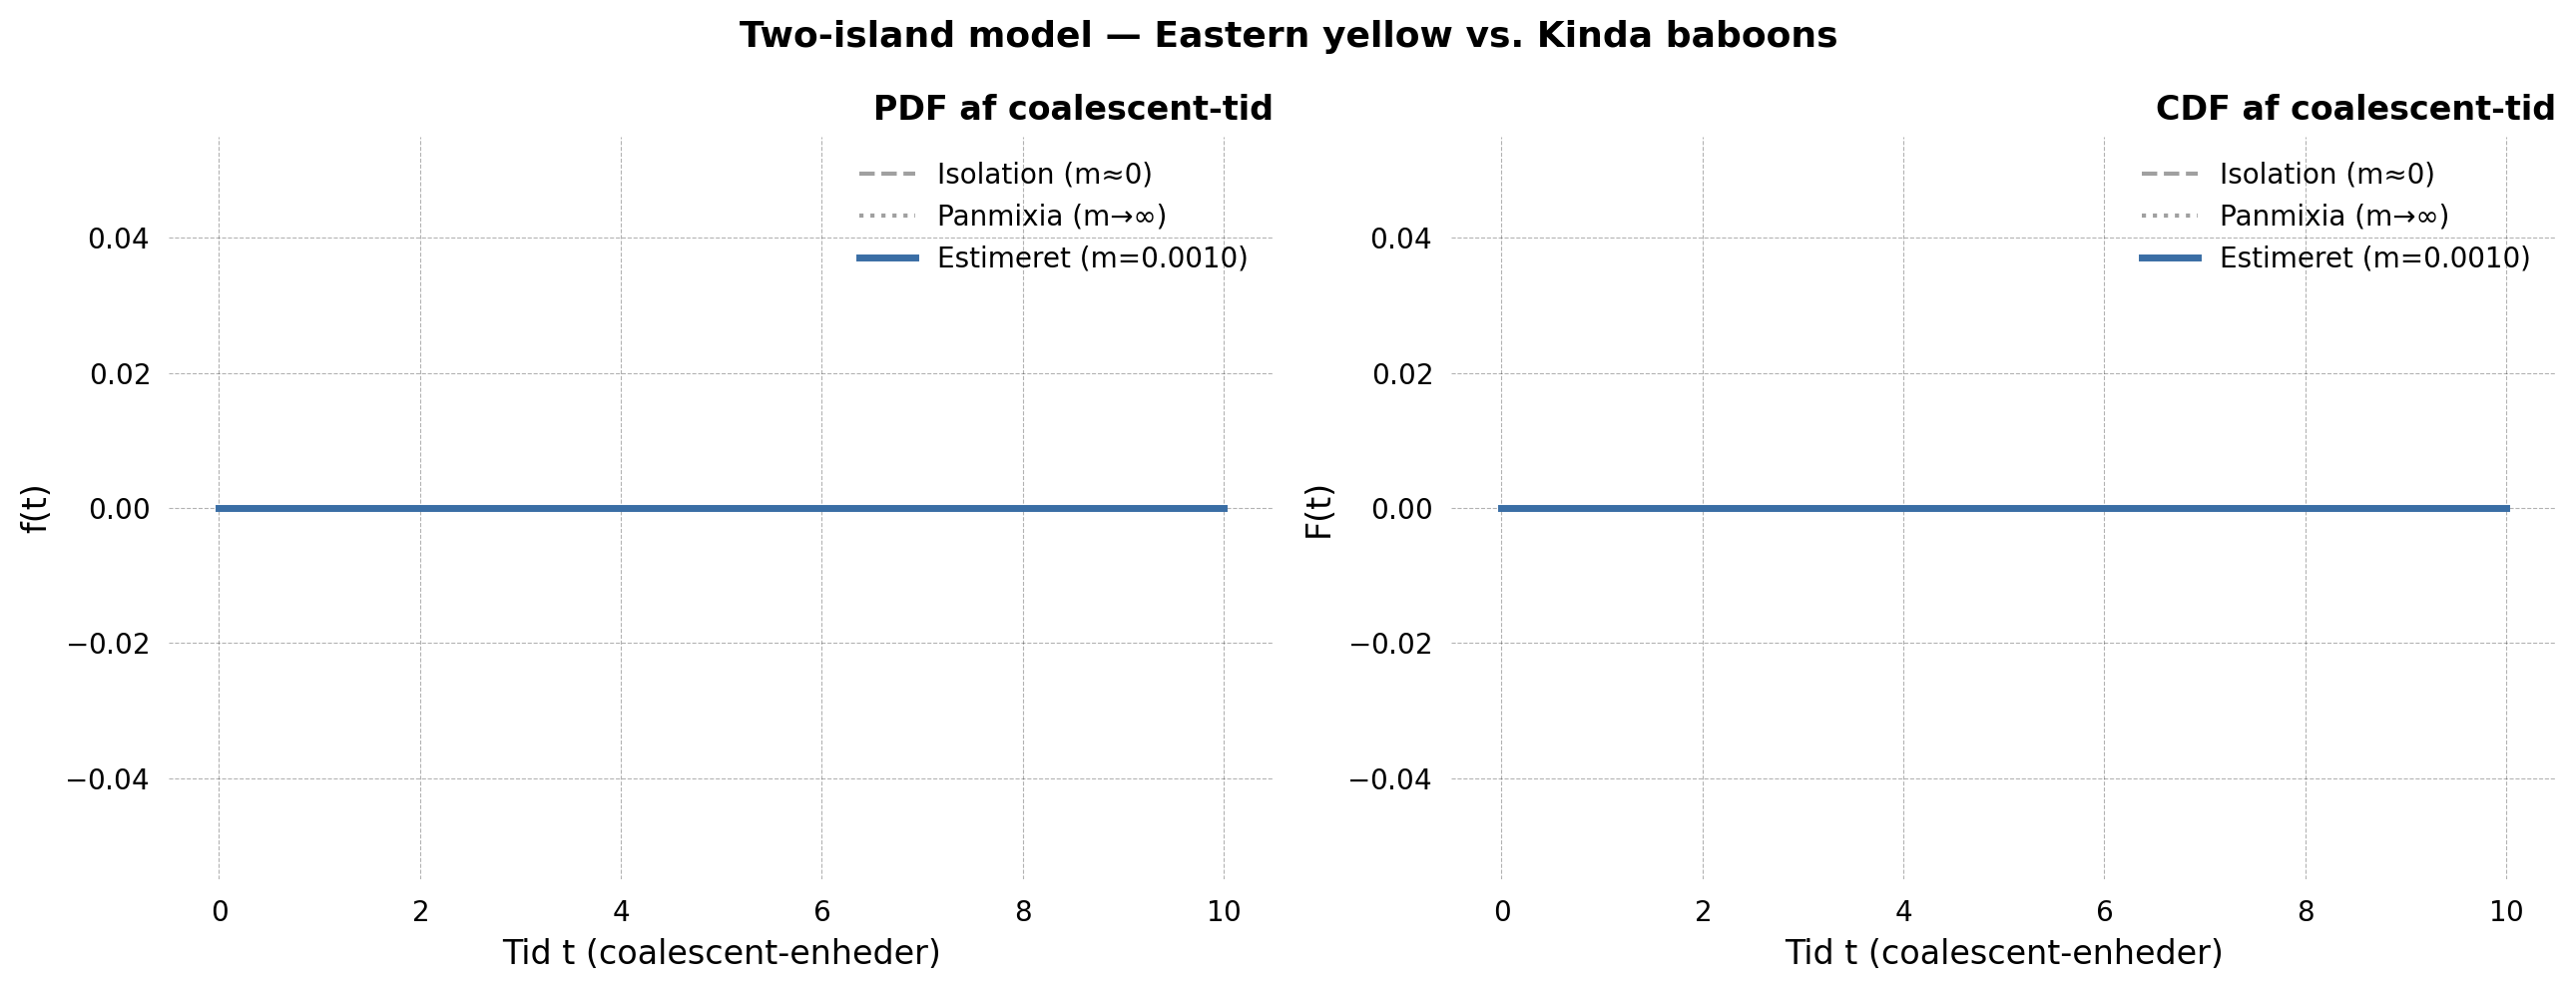

In [19]:
# Byg graf med optimerede parametre
graph_opt = Graph(
    two_island_model,
    ipv=[1, 1],
    N1=1.0,
    N2=N2_opt,
    m12=m_opt,
    m21=m_opt,
)

# Beregn teoretisk PDF
t_plot    = np.linspace(0, 10, 300)
pdf_model = graph_opt.pdf(t_plot)
cdf_model = graph_opt.cdf(t_plot)

# Sammenlign med standard (m=0, isolation) og panmixia
graph_iso = Graph(two_island_model, ipv=[1, 1], N1=1.0, N2=N2_opt, m12=1e-6, m21=1e-6)
graph_pan = Graph(two_island_model, ipv=[1, 1], N1=1.0, N2=N2_opt, m12=10.0, m21=10.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PDF
axes[0].plot(t_plot, graph_iso.pdf(t_plot), "--", color="#A0A0A0", lw=1.5, label="Isolation (m≈0)")
axes[0].plot(t_plot, graph_pan.pdf(t_plot), ":",  color="#A0A0A0", lw=1.5, label="Panmixia (m→∞)")
axes[0].plot(t_plot, pdf_model, "-",  color="#3A6EA5", lw=2.5, label=f"Estimeret (m={m_opt:.4f})")
axes[0].set_xlabel("Tid t (coalescent-enheder)", fontsize=12)
axes[0].set_ylabel("f(t)", fontsize=12)
axes[0].set_title("PDF af coalescent-tid", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# CDF
axes[1].plot(t_plot, graph_iso.cdf(t_plot), "--", color="#A0A0A0", lw=1.5, label="Isolation (m≈0)")
axes[1].plot(t_plot, graph_pan.cdf(t_plot), ":",  color="#A0A0A0", lw=1.5, label="Panmixia (m→∞)")
axes[1].plot(t_plot, cdf_model, "-",  color="#3A6EA5", lw=2.5, label=f"Estimeret (m={m_opt:.4f})")
axes[1].set_xlabel("Tid t (coalescent-enheder)", fontsize=12)
axes[1].set_ylabel("F(t)", fontsize=12)
axes[1].set_title("CDF af coalescent-tid", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Two-island model — Eastern yellow vs. Kinda baboons",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_fit.png", dpi=150, bbox_inches="tight")
plt.show()

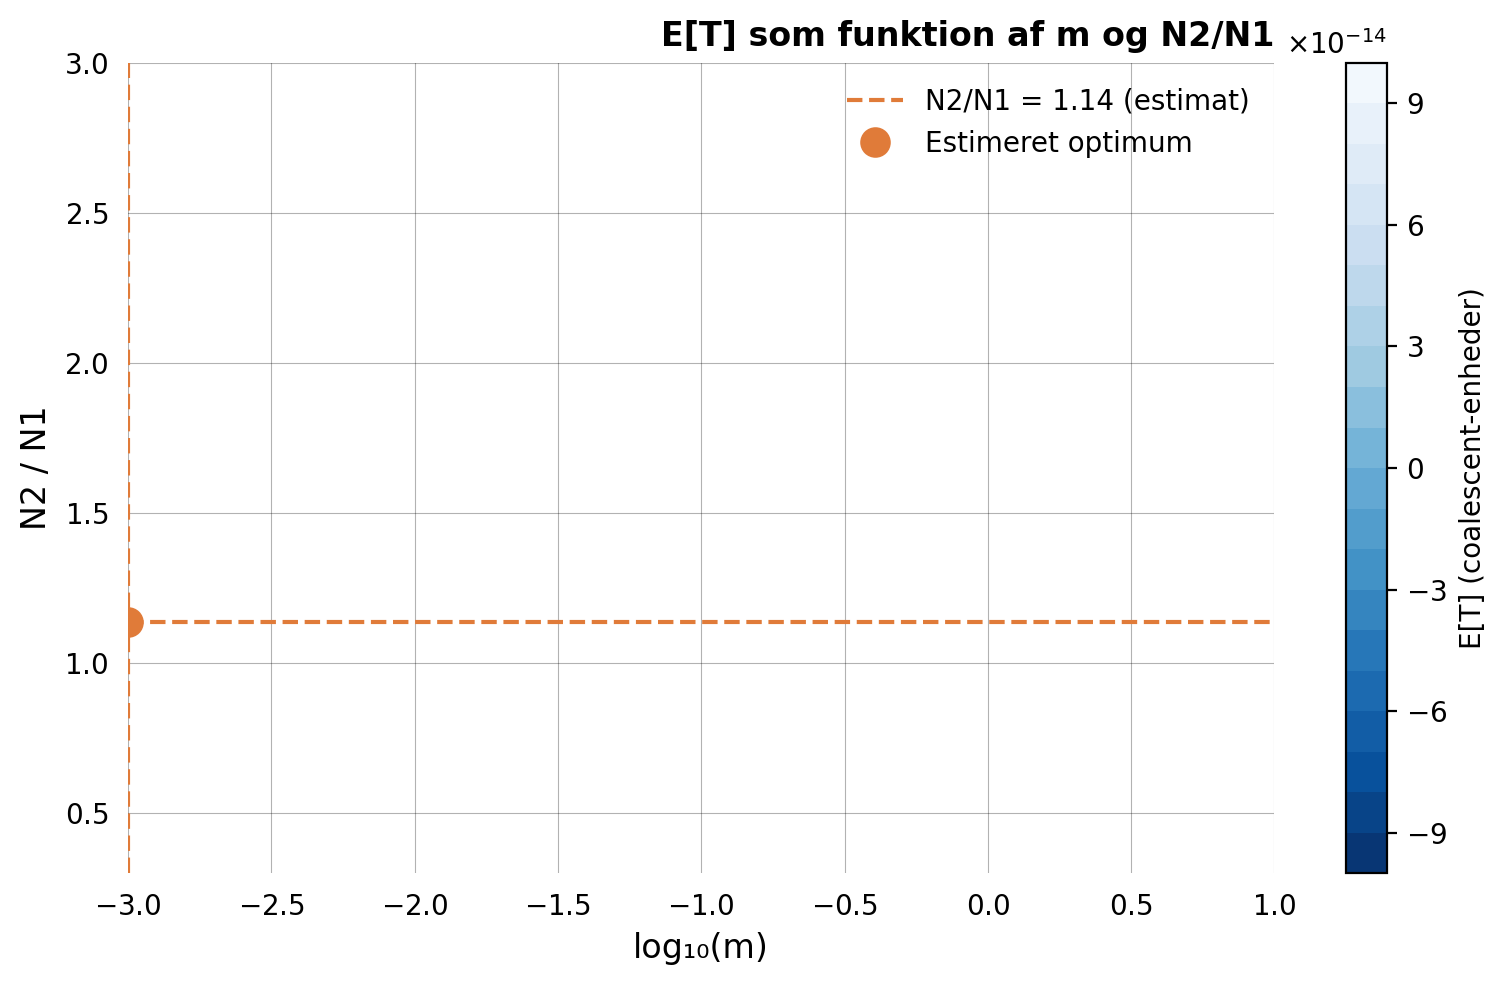

In [ ]:
# Likelihood-overfladen: E[T] som funktion af m og N2/N1
m_ax   = np.logspace(-3, 1, 30)
N2_ax  = np.linspace(0.3, 3.0, 30)
MM, NN = np.meshgrid(m_ax, N2_ax)

ET_surface = np.zeros_like(MM)
for i in range(MM.shape[0]):
    for j in range(MM.shape[1]):
        try:
            g = Graph(two_island_model, ipv=[1, 1],
                      N1=1.0, N2=NN[i, j], m12=MM[i, j], m21=MM[i, j])
            ET_surface[i, j] = g.expectation()
        except Exception:
            ET_surface[i, j] = np.nan

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(np.log10(MM), NN, ET_surface, levels=20, cmap="Blues_r")
plt.colorbar(cf, ax=ax, label="E[T] (coalescent-enheder)")

# Marker estimat og målværdi
ax.axhline(y=N2_opt, color="#E07B39", linestyle="--", lw=1.5, label=f"N2/N1 = {N2_opt:.2f} (estimat)")
ax.axvline(x=np.log10(m_opt), color="#E07B39", linestyle="--", lw=1.5)
ax.plot(np.log10(m_opt), N2_opt, "o", color="#E07B39", ms=10, label="Estimeret optimum")

ax.set_xlabel("log₁₀(m)",  fontsize=12)
ax.set_ylabel("N2 / N1",    fontsize=12)
ax.set_title("E[T] som funktion af m og N2/N1", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "ET_surface.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Stikprøver fra modellen vs. observeret SFS
# Jeg simulerer coalescent-tider og sammenligner med empirisk SFS-form

n_sim = 50_000
samples = graph_opt.sample(n_sim)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram af simulerede coalescent-tider
axes[0].hist(samples, bins=80, density=True, color="#3A6EA5", alpha=0.6, label="Simuleret")
axes[0].plot(t_plot, pdf_model, color="#E07B39", lw=2, label="Teoretisk PDF")
axes[0].set_xlabel("Coalescent-tid", fontsize=12)
axes[0].set_ylabel("Tæthed",         fontsize=12)
axes[0].set_title(f"Simulerede coalescent-tider (n={n_sim:,})", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# Observeret vs. forventet SFS (normaliseret)
x_sfs = np.arange(1, len(sfs_yellow_norm) + 1)
axes[1].bar(x_sfs - 0.2, sfs_yellow_norm.values, width=0.35,
            color="#E07B39", alpha=0.8, label="Observeret (Eastern yellow)")
axes[1].bar(x_sfs + 0.2, sfs_kinda_norm.values[:len(sfs_yellow_norm)], width=0.35,
            color="#5B8DB8", alpha=0.8, label="Observeret (Kinda)")
axes[1].set_xlabel("Minor allele count k", fontsize=12)
axes[1].set_ylabel("Relativ frekvens",     fontsize=12)
axes[1].set_title("Observeret (foldet) SFS", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].set_xlim(0.5, min(15, len(sfs_yellow_norm)) + 0.5)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Two-island model: simulering og data", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "simulation_vs_data.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Simuleret gennemsnit: {samples.mean():.4f}")
print(f"Teoretisk E[T]:       {graph_opt.expectation():.4f}")

## 9. Fortolkning og næste skridt

### Opsummering af resultater

In [ ]:
# Saml alle resultater i en tabel
results = {
    "N1 (eastern yellow)": f"{N1_ref:,}",
    "N2 (Kinda)": f"{N2_abs:,.0f}",
    "m (migration per linje)": f"{m_opt:.6f}",
    "M = 4*N1*m": f"{M_scaled:.3f}",
    "E[T] (model)": f"{graph_opt.expectation():.4f}",
    "E[T] (target fra data)": f"{ET_target:.4f}",
    "Tajima's D (eastern yellow)": f"{stats_yellow['tajima_d']:.4f}",
    "Tajima's D (Kinda)": f"{stats_kinda['tajima_d']:.4f}",
}

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Værdi"])
print(results_df.to_string())
results_df.to_csv(OUT_DIR / "two_island_results.csv")
print("\nResultater gemt: output/two_island_results.csv")

**To-island modellens begrænsninger her:**

En simpel to-island model antager konstant, symmetrisk migration og konstante populationsstørrelser. Artiklens resultater viser imidlertid at:

1. **Western yellow baboons har input fra *tre* linjer** — de er ikke blot en blanding af to populationer
2. **Migrationen er primært mandsdrevet** — X-kromosom vs. autosom analysen viser asymmetri
3. **Populationsstørrelserne har ændret sig over tid** — MSMC2-analyserne viser et fald for ~1 million år siden

Disse observationer motiverer direkte:
- **Notebook 3:** IM-modellen (Isolation with Migration) — tilføjer en split-tid og tillader asymmetrisk migration
- **Notebook 4:** Tidsinhomogen model — tillader migrationrater der varierer over tid, samt ghost-populationer

### Næste skridt: Notebook 3 — IM-modellen
Jeg udvider to-island modellen med en eksplicit split-begivenhed og asymmetrisk migration for at modellere den mere realistiske evolutionære historie.